# Movie Recommendation System using Collaborative Filtering
## Objective
Build a beginner-friendly recommendation system using MovieLens dataset and understand the intuition behind Collaborative Filtering.


## What is a Recommendation System?

A Recommendation System is a tool that helps users discover items they are most likely to like from a very large set of options.  
Instead of showing everything to everyone, it **personalizes suggestions** based on user behavior, preferences, or similarities with others.

In simple words:
> A recommendation system predicts *“What should I show this user next?”*

### Simple Real-Life Example

Imagine a small classroom with 4 students and 5 movies.

| Student | Movies they liked |
|--------|------------------|
| A | Avengers, Iron Man |
| B | Avengers, Iron Man, Thor |
| C | Titanic, Notebook |
| D | Titanic |

Now a new question:
> What movie should we recommend to Student A?

We notice:
- Student A and Student B like the same movies (Avengers, Iron Man)
- Student B also liked **Thor**

So we recommend:
> **Thor to Student A**

This is the core idea of a recommendation system:
> “If two people have similar tastes, what one likes can be recommended to the other.”


In [47]:
import pandas as pd


ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
links = pd.read_csv('links.csv')
tags = pd.read_csv('tags.csv')

In [48]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [49]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [50]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [51]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


## What is Collaborative Filtering?

Collaborative Filtering is one of the most popular and powerful approaches to build a recommendation system.  
It works on a very simple idea:

> “People who have similar tastes in the past will have similar tastes in the future.”

Instead of focusing on the features of the movies (like genre, actors, or year), collaborative filtering focuses only on:
- Users
- Their ratings
- Their behavior

It learns from the *collective experience* of users. That’s why it is called **collaborative**.

### Types of Collaborative Filtering

There are two main types:

1. **User-Based Collaborative Filtering**  
   - Find users similar to the target user  
   - Recommend movies that similar users liked  

2. **Item-Based Collaborative Filtering**  
   - Find movies similar to the movies the user liked  
   - Recommend those similar movies

### What Data Does Collaborative Filtering Need?

Only three things:
- User ID
- Movie ID
- Rating

That’s why the MovieLens dataset is perfect for this approach.

In [52]:
data = pd.merge(ratings, movies, on='movieId')

In [53]:
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [54]:
data.drop(columns=['timestamp'], inplace=True)

In [55]:
data.head()

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


This tells us the scale of our recommendation system: how many people and how many movies we are dealing with

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming data is already merged
# data = pd.merge(ratings, movies, on="movieId")

print("Total ratings:", len(data))
print("Total users:", data["userId"].nunique())
print("Total movies:", data["movieId"].nunique())

Total ratings: 100836
Total users: 610
Total movies: 9724


## Ratings distribution

Most ratings are between 3 and 5. That means users usually rate movies they already like.
This bias is common in real recommendation systems.

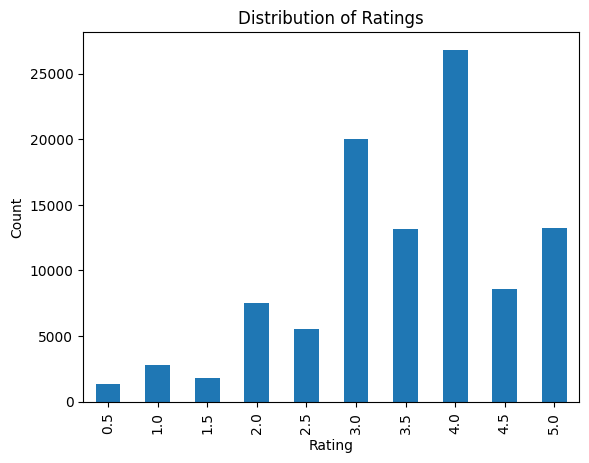

In [ ]:
data["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## Number of ratings per user (User activity)
users are very active, most users rate very few movies.
Collaborative filtering depends heavily on active users.

In [ ]:
user_ratings = data.groupby("userId")["rating"].count()

user_ratings.describe()


count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

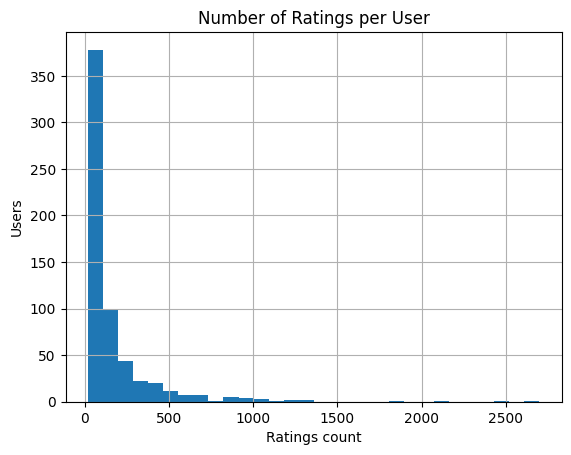

In [ ]:
user_ratings.hist(bins=30)
plt.title("Number of Ratings per User")
plt.xlabel("Ratings count")
plt.ylabel("Users")
plt.show()


## Number of ratings per movie (Movie popularity)
- Some movies are extremely popular, some are almost unseen.
Popular movies dominate recommendations if we are not careful.

In [ ]:
movie_ratings = data.groupby("movieId")["rating"].count()

movie_ratings.describe()


count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

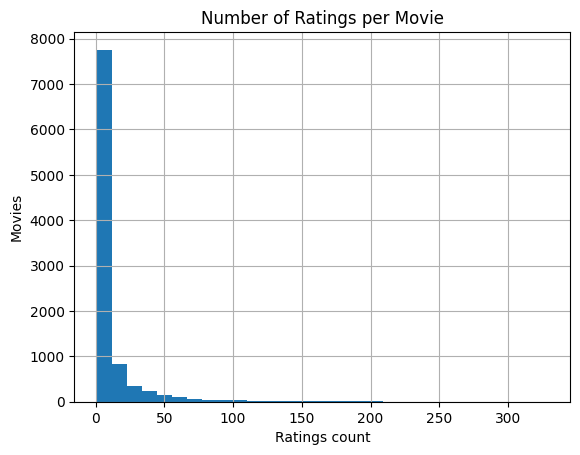

In [ ]:
movie_ratings.hist(bins=30)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings count")
plt.ylabel("Movies")
plt.show()


## Why Do We Calculate Sparsity?

Before building any recommendation system, we need to understand how much information we actually have.


In [ ]:
n_users = data["userId"].nunique()
n_movies = data["movieId"].nunique()
n_ratings = len(data)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Sparsity of matrix: {sparsity*100:.2f}%")


Sparsity of matrix: 98.30%


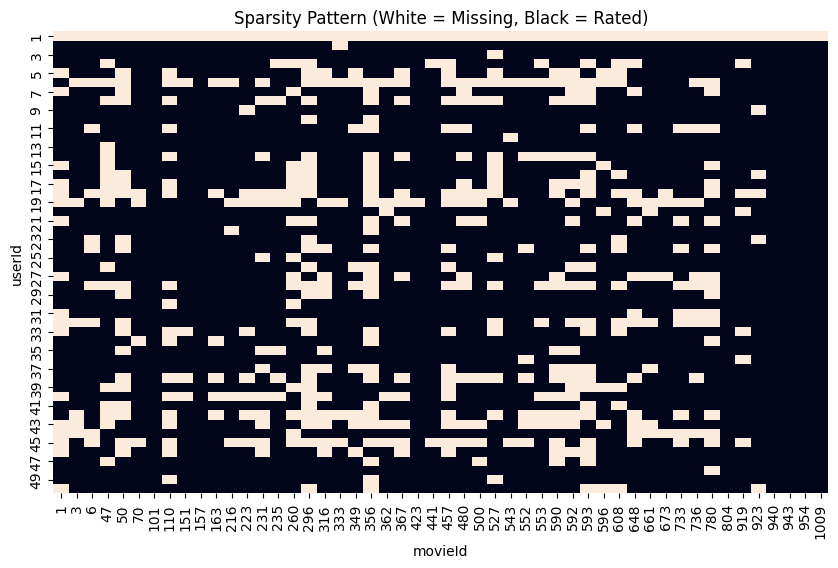

In [ ]:
sample_users = data["userId"].unique()[:50]
sample_movies = data["movieId"].unique()[:50]

sample_matrix = data[
    (data["userId"].isin(sample_users)) &
    (data["movieId"].isin(sample_movies))
].pivot(index="userId", columns="movieId", values="rating")

plt.figure(figsize=(10,6))
sns.heatmap(sample_matrix.notna(), cbar=False)
plt.title("Sparsity Pattern (White = Missing, Black = Rated)")
plt.show()


In [ ]:
movie_stats = data.groupby("title").agg({
    "rating": ["mean", "count"]
})

movie_stats.columns = ["avg_rating", "rating_count"]
movie_stats.sort_values("rating_count", ascending=False).head(10)


,avg_rating,rating_count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224




## Types of Collaborative Filtering Approaches

There are four major ways collaborative filtering systems are built:

1. **Memory-Based**
   - Uses similarity directly on the user–movie matrix  
   - Example: User-based and Item-based filtering  
   - Easy to understand  

2. **Model-Based**
   - Uses machine learning models (like SVD, Matrix Factorization)  
   - More scalable and accurate  

3. **Hybrid**
   - Combines collaborative filtering + content-based filtering  

4. **Deep Learning**
   - Uses neural networks and embeddings  
   - Used in large-scale platforms like Netflix and YouTube  

In this tutorial, we focus on **Memory-Based Collaborative Filtering** because:
- It is intuitive  
- Beginner-friendly  
- Shows the foundation clearly  

---

## Measuring Similarity Between Users

To find similar users, we measure how close their rating patterns are.  
One popular method is **Cosine Similarity**.

It is defined as:

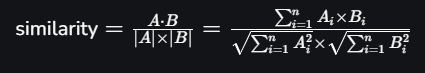


---




### Small Example

Suppose we have ratings like this:

| User | Movie A | Movie B | Movie C |
|------|--------|--------|--------|
| User 1 | 5 | 4 | ? |
| User 2 | 5 | 4 | 5 |
| User 3 | 1 | 2 | 5 |

User 1 and User 2 have very similar ratings:
- Both love Movie A
- Both like Movie B

User 2 also rated Movie C as 5.  
So we recommend **Movie C to User 1**.

But we will not recommend Movie C to User 3 because their taste is very different.



In [ ]:
user_movie_matrix = data.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

print("\nUser–Movie Matrix (Sample View, NaN shown as '-')")
print(user_movie_matrix.iloc[:5, :10].fillna("-"))



User–Movie Matrix (Sample View, NaN shown as '-')
movieId   1  2    3  4  5    6  7  8  9  10
userId                                     
1        4.0  -  4.0  -  -  4.0  -  -  -  -
2          -  -    -  -  -    -  -  -  -  -
3          -  -    -  -  -    -  -  -  -  -
4          -  -    -  -  -    -  -  -  -  -
5        4.0  -    -  -  -    -  -  -  -  -


In [ ]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)


## Computing User Similarity with Cosine Similarity

In this step, we calculate how similar each user is to every other user based on their movie rating patterns.




In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_matrix_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)


## Recommendation Function: Generating Personalized Movie Suggestions

This function creates movie recommendations for a given user using collaborative filtering.

First, we find users who are most similar to the target user. These users act like a “friend circle” whose opinions we trust the most.  
We select only the top **K similar users**, where **K** means:



In [ ]:
def recommend_movies(user_id, n_recommendations=5, k=10):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    similar_users = similar_users.drop(user_id)
    similar_users = similar_users.head(k)

    user_rated_movies = user_movie_matrix_filled.loc[user_id]
    watched_movies = user_rated_movies[user_rated_movies > 0].index

    weighted_scores = pd.Series(0, index=user_movie_matrix_filled.columns)
    similarity_sum = similar_users.sum()

    for other_user, similarity_score in similar_users.items():
        other_user_ratings = user_movie_matrix_filled.loc[other_user]
        weighted_scores += similarity_score * other_user_ratings

    weighted_scores = weighted_scores / similarity_sum
    weighted_scores = weighted_scores.drop(watched_movies)

    recommended_movie_ids = weighted_scores.sort_values(ascending=False)\
                                        .head(n_recommendations).index

    recommendations = movies[movies["movieId"].isin(recommended_movie_ids)][["movieId", "title"]]
    return recommendations


## Why We Normalize or Weight Ratings

Different users rate differently:
- Some are strict  
- Some are generous  

By weighting ratings with similarity:
- Close users matter more  
- Distant users matter less  

This creates a fair recommendation.

In [ ]:
# Example: Recommend movies for user 1
recommend_movies(user_id=1, n_recommendations=10)


,movieId,title
474,541,Blade Runner (1982)
507,589,Terminator 2: Judgment Day (1991)
659,858,"Godfather, The (1972)"
706,924,2001: A Space Odyssey (1968)
793,1036,Die Hard (1988)
902,1200,Aliens (1986)
922,1221,"Godfather: Part II, The (1974)"
1211,1610,"Hunt for Red October, The (1990)"
1445,1968,"Breakfast Club, The (1985)"
2078,2762,"Sixth Sense, The (1999)"


## Why Collaborative Filtering is Powerful

Advantages:
- Highly personalized  
- Adapts automatically as user preferences change  
- Does not require movie features  
- Learns directly from user behavior  

This is why most modern recommendation systems rely heavily on collaborative filtering.

---

## Challenges of Collaborative Filtering

1. **Scalability**
   - More users → heavier computation  

2. **Cold Start Problem**
   - New users or new movies have no ratings  

3. **Sparsity**
   - Most users rate very few movies  

4. **Limited Diversity**
   - Recommends what is already popular in a user’s cluster  

---
